<a href="https://colab.research.google.com/github/computacao-aplicada/lab01-eda-LeandroDeFRusso/blob/main/Leandro_Classificadores_Wine_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Link para baixar as planilhas
#https://archive.ics.uci.edu/dataset/186/wine+quality

In [ ]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualizações
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Separação treino/teste
from sklearn.model_selection import train_test_split

# Classificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
# Carregando o dataset
winequality_white = pd.read_csv('winequality-white.csv',sep=';')
winequality_red = pd.read_csv('winequality-red.csv',sep=';')

winequality_red['type'] = 'red'
winequality_white['type'] = 'white'

df = pd.concat([winequality_red, winequality_white] , ignore_index=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [ ]:
df.shape

(6497, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
# Estatísticas descritivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


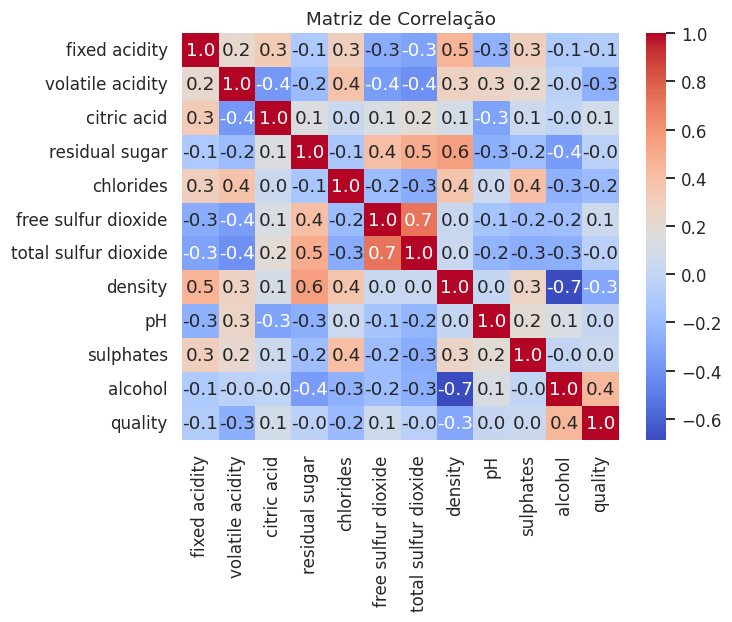

In [ ]:
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Matriz de Correlação')

plt.show()

---
## **1° Afirmação:**

Vinhos com maior acidez volátil tendem a apresentar uma menor qualidade.

/tmp/ipykernel_679/4288854030.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['quality'], df['volatile acidity']], labels=['quality', 'volatile acidity'])


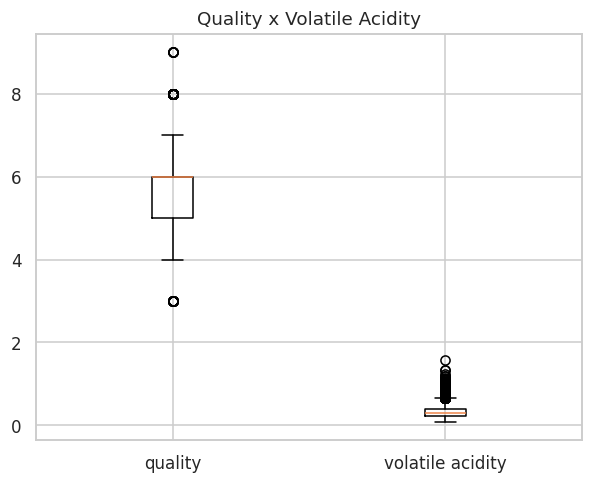

In [ ]:
plt.boxplot([df['quality'], df['volatile acidity']], labels=['quality', 'volatile acidity'])
plt.title('Quality x Volatile Acidity')
plt.show()

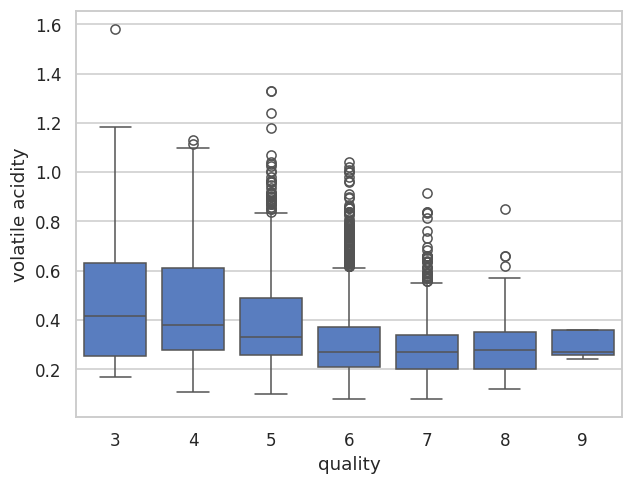

In [ ]:
sns.boxplot(x="quality", y="volatile acidity", data=df)
plt.show()

## **Interpretação:**

A partir dos boxplots gerados acima, é possível notar que os resultados indicam que os vinhos com maior acidez volátil tendem a receber menores notas de qualidade. Nota-se que, conforme a qualidade aumenta, os valores de acidez volátil tendem a diminuir, indicando uma possível relação negativa entre as variáveis. Essa associação negativa também é percebida na correlação entre as variáveis, que detém uma correlação de aproximadamente -0,3.

---
## **2° Afirmação:**

Vinhos brancos possuem maior concentração de dióxido de enxofre total e dióxido de enxofre livre.

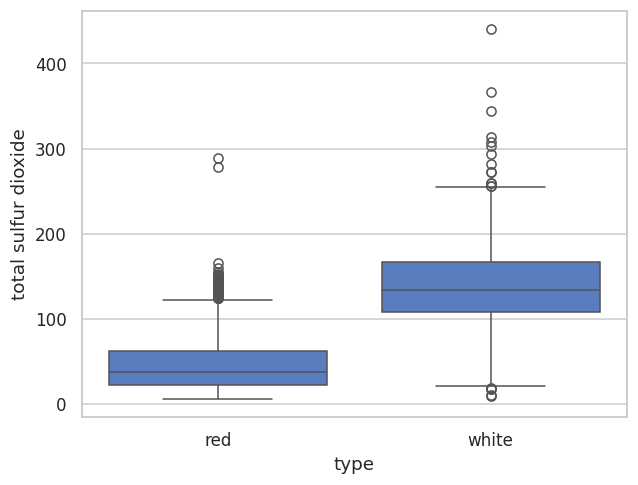

In [ ]:
sns.boxplot(x='type', y='total sulfur dioxide', data=df)
plt.show()

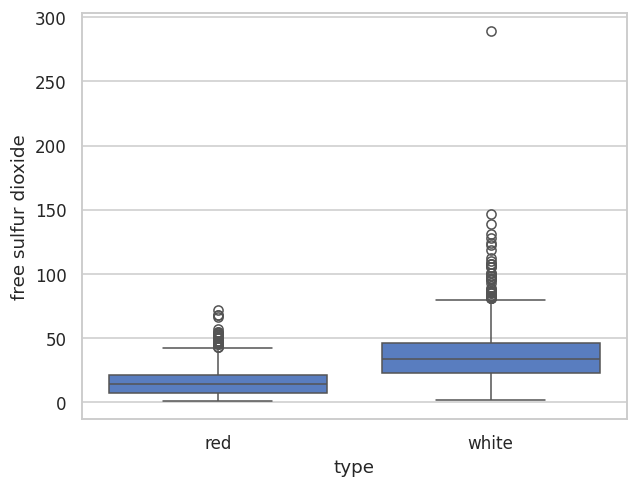

In [ ]:
sns.boxplot(x='type', y='free sulfur dioxide', data=df)
plt.show()

In [ ]:
df.groupby('type')[['free sulfur dioxide', 'total sulfur dioxide']].mean()

,free sulfur dioxide,total sulfur dioxide
type,,
red,15.874922,46.467792
white,35.308085,138.360657


## **Interpretação:**

A partir dos boxplots gerados, observa-se que os vinhos brancos apresentam maiores concentrações de dióxido de enxofre total e livre em relação aos vinhos tintos. Essa diferença também é percebida nas médias de cada variável por tipo de vinho. Além disso, a correlação positiva de aproximadamente 0,7 entre dióxido de enxofre total e livre indica uma forte associação entre essas variáveis.

---
## **3° Afirmação:**

Açúcar residual e densidade apresentam uma tendência linear positiva.

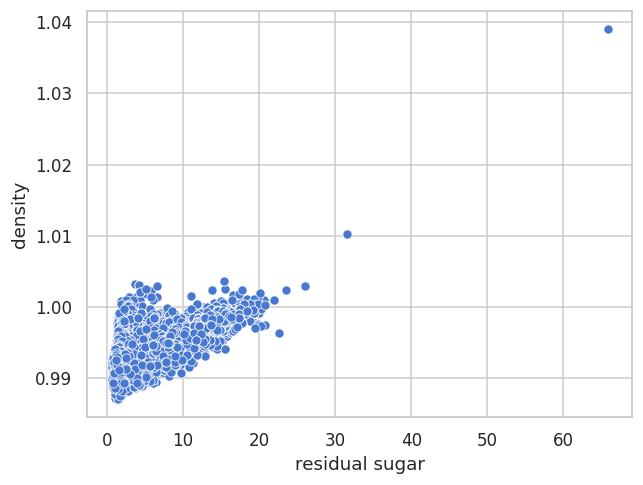

In [ ]:
sns.scatterplot(x='residual sugar', y='density', data=df)
plt.show()

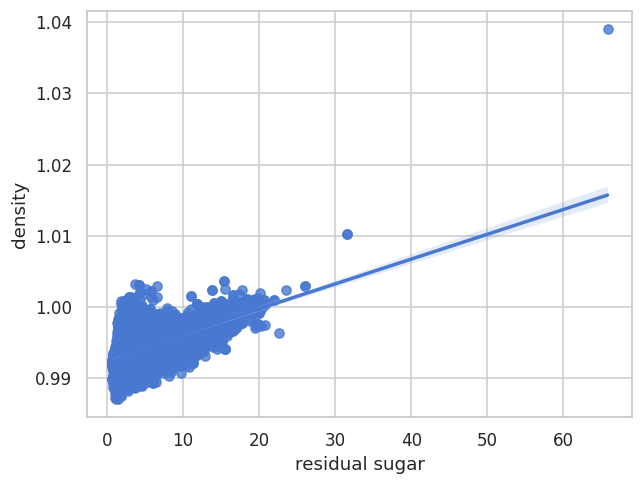

In [ ]:
sns.regplot(x='residual sugar', y='density', data=df)
plt.show()

## **Interpretação:**

A partir dos gráficos gerados acima, nota-se que as variáveis de residual de açúcar e densidade possuem uma tendência de crescente linear. Ou seja, os maiores valores de açúcar residual tendem a estar associados a maiores valores de densidade. Essa tendência também é comprovada no gráfico de correlação, que apresenta aproximadamente uma correlação de 0,6.